In [ ]:
from pathlib import Path
from platform import python_version
import importlib
import logging
import sys
import os
    
logging.basicConfig(
    format="%(levelname)s: %(message)s", stream=sys.stdout, level=logging.INFO
)
logger = logging.getLogger("__notebook__")
logger.info("Interpreting with python {}".format(python_version()))
# Loading markov model directory as module into jupyter notebook
module_dir = Path(os.getcwd()).parent.resolve()
data_dir = module_dir / "data"
logger.info(f"Module directory: {module_dir}")

if str(module_dir) not in sys.path:
    sys.path.insert(1, str(module_dir))
    logger.info("Module path inserted into system path, ready to use")
else:
    logger.info("Module path already inserted into system paths")

# Temp solution to load as module
try:
    from model import markov_chain as mc
    from model import probabilistic_analysis as psa
    from model import visualization
    from model import constants
    from model import utils

    # Force to update module
    importlib.reload(mc)
    importlib.reload(psa)
    importlib.reload(visualization)
    importlib.reload(constants)
    importlib.reload(utils)
    logger.info("Module reloaded")
except ModuleNotFoundError as e:
    logger.error(f"Unable to import module: {e.msg}")

INFO: Interpreting with python 3.13.7
INFO: Module directory: /home/mohammad/projects/Thesis/hemophilia
INFO: Module path inserted into system path, ready to use
INFO: Module reloaded


In [2]:
import numpy as np


logger.info(
    """\n
    Simplified Final Markov Model Structure

                                          <-----  Bleed Resolution  <-----
     -----------------------------------------------------------------------------------------------------------
     |                                                                                 |                       |
  [Healthy | Mild | Moderate | Severe] <Pettersson decremented utility reward> -> [LT_Bleeding] -> [Death]     |
     |                                                                                                         |
     |-----------------------------------------------> [Bleeding] ---------------------------------------------|
     |                                                                                                         |
      -----------------------------------------------> [Hemarthrosis] <Increment pettersson score> ------------
"""
)

# INPUTS
sobol_sample_size = 32  # simulated sample final count follows: N * (D + 2)
n_cycles = constants.SHORT_TERM_CYCLE_COUNTS
ssp = constants.SHORT_SIMULATION_START_AGE_IN_WEEK  # simulation starting point
estate = constants.START_STATE  # Entrance state
stats = constants.STATES

logger.info(
    f"""
    Model initialized with:
    - Base sample size: {sobol_sample_size}
    - Simulation steps: {n_cycles} ({n_cycles / constants.WOY} Years)
    - Simulation starting point: {ssp} ({ssp / constants.WOY} YO)
    """
)

chains = []
chain_main = mc.Chain(
    name="main",
    states=stats,
    matrix=np.eye(N=len(stats), M=len(stats), dtype=np.float64),
)
chains.append(chain_main)

INFO: 

    Simplified Final Markov Model Structure

                                          <-----  Bleed Resolution  <-----
     -----------------------------------------------------------------------------------------------------------
     |                                                                                 |                       |
  [Healthy | Mild | Moderate | Severe] <Pettersson decremented utility reward> -> [LT_Bleeding] -> [Death]     |
     |                                                                                                         |
     |-----------------------------------------------> [Bleeding] ---------------------------------------------|
     |                                                                                                         |
      -----------------------------------------------> [Hemarthrosis] <Increment pettersson score> ------------

INFO: 
    Model initialized with:
    - Base sample size: 32
    - Simulation st

INFO: Sampling ABR values took 0.13 seconds
INFO: Generated data length: 704


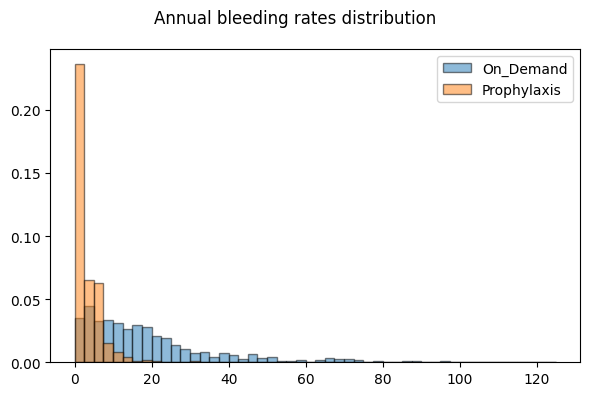

In [3]:
# Short term simulation
from time import time
import matplotlib.pyplot as plt
import seaborn as sns

import model.types

run_time = time()
# Note: For the sake of statistical comparison n_samples should be in same size over different population in each treatment arms
on_demand_sampled_abr = psa.sample_population_abrs(
    treatment=model.types.Treatment.ON_DEMAND, n_samples=sobol_sample_size, visualize=False
)
prophylaxis_sampled_abr = psa.sample_population_abrs(
    treatment=model.types.Treatment.PROPHYLAXIS, n_samples=sobol_sample_size, visualize=False
)
exc_time = round((time() - run_time), 2)
logger.info(f"Sampling ABR values took {exc_time} seconds")
logger.info(f"Generated data length: {len(on_demand_sampled_abr)}")

# Drawing population ABR distribution
plt.figure(figsize=(6, 4))
plt.suptitle("Annual bleeding rates distribution")
on_demand_hist = plt.hist(
    on_demand_sampled_abr,
    50,
    range=(0, 125),
    density=True,
    alpha=0.5,
    edgecolor="black",
    label="On_Demand",
)
prophylaxis_hist = plt.hist(
    prophylaxis_sampled_abr,
    50,
    range=(0, 125),
    density=True,
    alpha=0.5,
    edgecolor="black",
    label="Prophylaxis",
)
plt.legend()
plt.tight_layout()

INFO: Patients average weight: 24.27 kg


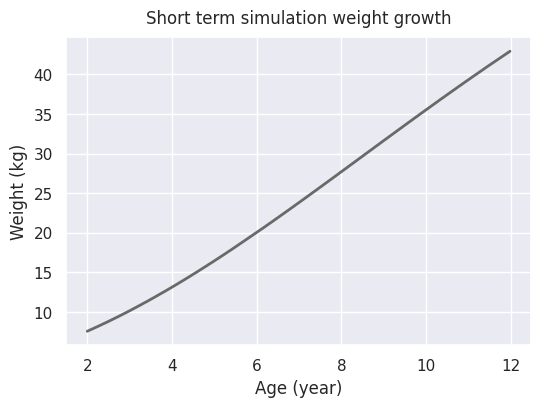

In [4]:
weights = [utils.cal_body_weight(n, b=ssp) for n in range(n_cycles)]
pairs: dict[int, float] = {(i + ssp): weight for i, weight in enumerate(weights)}
average_weight = np.mean(list(pairs.values()))

logger.info(f"Patients average weight: {round(average_weight, 2)} kg")

# Drawing patient weight growth graph
sns.set_theme()
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
X = np.array(list(pairs.keys()))
Y = np.array(list(pairs.values()))
ax.plot(X / constants.WOY, Y, color="dimgray", linestyle="-", linewidth=2)
text = ax.set_title("Short term simulation weight growth", pad=10)
y_text = ax.set_ylabel("Weight (kg)")
x_text = ax.set_xlabel("Age (year)")

In [ ]:
import model.types


markov = mc.MarkovChains(
    chains=chains,
    entrance="Healthy",
    entrance_chain="main",
    steps=n_cycles,
    conditions=None,
)
logger.info(f"Starting simulations for {n_cycles} steps (weeks)")
on_demand_results = psa.parallelize_markov_chain(
    simulation_name="on_demand",
    worker_inputs=[
        model.types.HemophiliaInput(
            treatment=model.types.Treatment.ON_DEMAND,
            abr=abr,
            ajbr=None,
            wbr=None,
            webr=None,
            wjbr=None,
        )
        for abr in on_demand_sampled_abr
    ],
    worker_func=psa.worker_function,
    markov_chain=markov,
)
prophylaxis_results = psa.parallelize_markov_chain(
    simulation_name="prophylaxis",
    worker_inputs=[
        model.types.HemophiliaInput(
            treatment=model.types.Treatment.PROPHYLAXIS,
            abr=abr,
            ajbr=None,
            wbr=None,
            webr=None,
            wjbr=None,
        )
        for abr in prophylaxis_sampled_abr
    ],
    worker_func=psa.worker_function,
    markov_chain=markov,
)

INFO: Starting simulations for 520 steps (weeks)


In [50]:
# Unwrap input outputs from results
on_demand_inputs, on_demand_outputs = on_demand_results
prophylaxis_inputs, prophylaxis_outputs = prophylaxis_results

In [7]:
SAMPLE_SIZE = len(on_demand_sampled_abr)
logger.info(f"{SAMPLE_SIZE:,} data generated to work with")

cols = list(psa.HemophiliaOutput.model_fields.keys())
cols.insert(0, "regimes")
cols.insert(1, "input_abr")

for key in ["arthropathy", "is_dead", "weights", "mean_weight", "person_year"]:
    cols.append(key)

logger.info("Dataframe Columns: \n {}".format(cols).replace(",", ",\n"))

INFO: 704 data generated to work with
INFO: Dataframe Columns: 
 ['regimes',
 'input_abr',
 'initial_state',
 'final_state',
 'steps',
 'path',
 'factor_consumption',
 'factor_costs',
 'annual_factor_consumption',
 'annual_factor_costs',
 'hemarthrosis',
 'qaly',
 'abr',
 'pettersson_score',
 'arthropathy',
 'is_dead',
 'weights',
 'mean_weight',
 'person_year']


In [10]:
import pandas as pd
import numpy as np


def truncate_weights_at_death(sequences: list["str"]):
    death_indices = [
        i
        for i, state in enumerate(sequences)
        if state
        and any(
            "death" in str(s).lower()
            for s in (state if isinstance(state, (list, tuple)) else [state])
        )
    ]

    if death_indices:
        # Use the first death occurrence
        death_index = death_indices[0]
        return weights[: death_index + 1]  # Include the death state

    # If no death found, return full weights
    return weights


def to_stage(pettersson_score_sequence: list[int | float] | np.ndarray):
    if isinstance(pettersson_score_sequence, list):
        pettersson_score_sequence = np.array(pettersson_score_sequence)
    if len(pettersson_score_sequence.shape) > 1:
        raise ValueError(
            f"Pettersson score array should be 1-D, shape: {pettersson_score_sequence.shape}"
        )
    if np.all(pettersson_score_sequence == 0):
        return "healthy"
    max_score = pettersson_score_sequence.max()
    if max_score < 0:
        raise ValueError("Invalid pettersson score")
    if max_score > 28:
        return "severe"
    elif max_score > 5:
        return "moderate"
    elif max_score <= 5:
        return "mild"
    else:
        raise ValueError(f"No stage defined for pettersson score: {max_score}")


run_time = time()
on_demand_df = pd.DataFrame(
    columns=cols,
    data={
        "regimes": "on_demand",
        "initial_state": [op.initial_state for op in on_demand_outputs],
        "final_state": [op.final_state for op in on_demand_outputs],
        "steps": [op.steps for op in on_demand_outputs],
        "input_abr": [op["abr"] for op in on_demand_inputs],
        "abr": [op.abr for op in on_demand_outputs],
        "hemarthrosis": [op.hemarthrosis for op in on_demand_outputs],
        "factor_consumption": [op.factor_consumption for op in on_demand_outputs],
        "qaly": [op.qaly for op in on_demand_outputs],
        "factor_costs": [op.factor_costs for op in on_demand_outputs],
        "annual_factor_consumption": [
            op.annual_factor_consumption for op in on_demand_outputs
        ],
        "annual_factor_costs": [op.annual_factor_costs for op in on_demand_outputs],
        "arthropathy": [to_stage(op.pettersson_score) for op in on_demand_outputs],
        "pettersson_score": [op.pettersson_score for op in on_demand_outputs],
        "is_dead": [True if "Death" in op.path else False for op in on_demand_outputs],
        "path": [op.path for op in on_demand_outputs],
        "weights": [truncate_weights_at_death(op.path) for op in on_demand_outputs],
    },
)

# ---- Dependent columns assignment ----
mean_weight = lambda x: round(np.array(x).mean(), 2)  # noqa: E731
person_year = lambda x: round(len(x) / constants.WOY, 2)  # noqa: E731

on_demand_df["mean_weight"] = on_demand_df["weights"].apply(mean_weight)
on_demand_df["person_year"] = on_demand_df["weights"].apply(person_year)
exc_time = round((time() - run_time), 2)
logger.info(f"Loading on_demand data with pandas took {exc_time} seconds")

run_time = time()
prophylaxis_df = pd.DataFrame(
    data={
        "regimes": "prophylaxis",
        "input_abr": [op["abr"] for op in prophylaxis_inputs],
        "initial_state": [op.initial_state for op in prophylaxis_outputs],
        "final_state": [op.final_state for op in prophylaxis_outputs],
        "steps": [op.steps for op in prophylaxis_outputs],
        "abr": [op.abr for op in prophylaxis_outputs],
        "hemarthrosis": [op.hemarthrosis for op in prophylaxis_outputs],
        "factor_consumption": [op.factor_consumption for op in prophylaxis_outputs],
        "qaly": [op.qaly for op in prophylaxis_outputs],
        "factor_costs": [op.factor_costs for op in prophylaxis_outputs],
        "annual_factor_consumption": [
            op.annual_factor_consumption for op in prophylaxis_outputs
        ],
        "annual_factor_costs": [op.annual_factor_costs for op in prophylaxis_outputs],
        "pettersson_score": [op.pettersson_score for op in prophylaxis_outputs],
        "arthropathy": [to_stage(op.pettersson_score) for op in prophylaxis_outputs],
        "is_dead": [
            True if "Death" in op.path else False for op in prophylaxis_outputs
        ],
        "path": [op.path for op in prophylaxis_outputs],
        "weights": [truncate_weights_at_death(op.path) for op in prophylaxis_outputs],
    },
    columns=cols,
)
prophylaxis_df["mean_weight"] = prophylaxis_df["weights"].apply(mean_weight)
prophylaxis_df["person_year"] = prophylaxis_df["weights"].apply(person_year)
exc_time = round((time() - run_time), 2)
logger.info(f"loading prophylaxis data with pandas took {exc_time} seconds")

df_raw = pd.concat([on_demand_df, prophylaxis_df])

# ---- Preprocessing ----
unnecessary_columns = ["initial_state", "steps", "path", "weights", "pettersson_score"]
df = df_raw.drop(columns=unnecessary_columns)
df = df.apply(lambda x: round(x, 2) if pd.api.types.is_numeric_dtype(x) else x)
df[(df["is_dead"] == False)].head(n=5)  # noqa: E712


INFO: Loading on_demand data with pandas took 0.38 seconds
INFO: loading prophylaxis data with pandas took 0.36 seconds


,regimes,input_abr,final_state,factor_consumption,factor_costs,annual_factor_consumption,annual_factor_costs,hemarthrosis,qaly,abr,arthropathy,is_dead,mean_weight,person_year
0,on_demand,23.72,Healthy,486387.0,33046.43,48638.7,3304.64,24.3,6.97,24.3,moderate,False,24.27,10.0
1,on_demand,0.25,Healthy,4532.0,307.92,453.2,30.79,0.2,9.13,0.2,healthy,False,24.27,10.0
2,on_demand,16.92,Healthy,419111.0,28475.52,41911.1,2847.55,17.4,7.30,17.9,moderate,False,24.27,10.0
3,on_demand,8.89,Healthy,196028.0,13318.66,19602.8,1331.87,9.8,7.87,9.8,moderate,False,24.27,10.0
5,on_demand,25.50,Healthy,514053.0,34926.13,51405.3,3492.61,25.0,6.95,25.4,moderate,False,24.27,10.0


In [48]:
df_alive = df[df["is_dead"] == False]  # noqa: E712
abs_diff = np.abs(df_alive["abr"] - df_alive["input_abr"])
f2 = lambda x: round(x, 2)  # noqa: E731
# Sums
logger.info(
    f"""
    Mean absolute differences of simulated annual bleeding rate vs model input abr value: {f2(abs_diff.mean())}, ({f2(abs_diff.std())})
    """
)

INFO: 
    Mean absolute differences of simulated annual bleeding rate vs model input abr value: 0.71, (1.19)
    


In [51]:
# TODO: Visualize model generated transition matrix, or store them as csv files

In [163]:
SIMULATED_YEARS = int(n_cycles / constants.WOY)
per_year = lambda x: x / SIMULATED_YEARS  # noqa: E731

MORT_RATE_OD = on_demand_df["is_dead"].mean() * 100
MORT_RATE_PRO = prophylaxis_df["is_dead"].mean() * 100
# Relative mortality reduction
RRR = (MORT_RATE_OD - MORT_RATE_PRO) / MORT_RATE_OD * 100
PREVENTED_DEATH = (
    (on_demand_df.is_dead.sum() - prophylaxis_df.is_dead.sum()) / SAMPLE_SIZE * 1000
)


# Delta values
DC = f2(prophylaxis_df["factor_costs"].sum() - on_demand_df["factor_costs"].sum())
DQ = f2(prophylaxis_df["qaly"].sum() - on_demand_df["qaly"].sum())
LG = f2(prophylaxis_df["person_year"].sum() - on_demand_df["person_year"].sum())
ICER_QALY = f2(DC / DQ)
ICER_LG = f2(DC / LG)
ACCEPTABLE_EXPENDITURE = constants.WTP_THRESHOLD * (DQ)
NMB = f2(ACCEPTABLE_EXPENDITURE - DC)

logger.info(
    f"""
    Population size (simulations): {SAMPLE_SIZE}
    Simulation length (year): {SIMULATED_YEARS}
    Increased factor costs: ${int(DC):,}
    Increased QALY: {DQ:,}
    Relative mortality reduction: {int(RRR)}%
    Number of death prevented (per 1000 person): {int(round(PREVENTED_DEATH))}
    Life years gained: {LG:,}
    
    [Annual]
    Annual increased factor cost: ${int(per_year(DC)):,}
    
    Incremental cost effectiveness ratio (DC/QALY): ${int(ICER_QALY):,}
    Incremental cost effectiveness ratio (DC/LYG): ${int(ICER_LG):,}
    New monetary benefits: ${int(NMB):,}
    
    Conclusion: Intervention {"was not" if NMB < 0 else "was"} cost effective
    """
)

logger.info(
    f"""
    [On Demand]
    Death (includes natural cause of death): {f2(MORT_RATE_OD)}%
    Joint outcome:
        - Healthy: {int(f2(on_demand_df.arthropathy.str.count("healthy").mean()) * 100)}%
        - Mild arthropathy: {int(f2(on_demand_df.arthropathy.str.count("mild").mean()) * 100)}%
        - Moderate arthropathy: {int(f2(on_demand_df.arthropathy.str.count("moderate").mean()) * 100)}%
        - Severe arthropathy: {int(f2(on_demand_df.arthropathy.str.count("severe").mean()) * 100)}%
    
    [Prophylaxis]
    Death (includes natural cause of death): {f2(MORT_RATE_PRO)}%
    Joint outcome:
        - Healthy: {int(f2(prophylaxis_df.arthropathy.str.count("healthy").mean()) * 100)}%
        - Mild arthropathy: {int(f2(prophylaxis_df.arthropathy.str.count("mild").mean()) * 100)}%
        - Moderate arthropathy: {int(f2(prophylaxis_df.arthropathy.str.count("moderate").mean()) * 100)}%
        - Severe arthropathy: {int(f2(prophylaxis_df.arthropathy.str.count("severe").mean()) * 100)}%
    """
)


INFO: 
    Population size (simulations): 704
    Simulation length (year): 10
    Increased factor costs: $30,100,787
    Increased QALY: 1,183.71
    Relative mortality reduction: 60%
    Number of death prevented (per 1000 person): 205
    Life years gained: 637.31
    
    [Annual]
    Annual increased factor cost: $3,010,078
    
    Incremental cost effectiveness ratio (DC/QALY): $25,429
    Incremental cost effectiveness ratio (DC/LYG): $47,231
    New monetary benefits: $-13,156,925
    
    Conclusion: Intervention was not cost effective
    
INFO: 
    [On Demand]
    Death (includes natural cause of death): 34.09%
    Joint outcome:
        - Healthy: 7%
        - Mild arthropathy: 37%
        - Moderate arthropathy: 52%
        - Severe arthropathy: 3%
    
    [Prophylaxis]
    Death (includes natural cause of death): 13.64%
    Joint outcome:
        - Healthy: 41%
        - Mild arthropathy: 55%
        - Moderate arthropathy: 5%
        - Severe arthropathy: 0%
    


In [ ]:
logger.info(
    f"""
    [Model outputs]
    Annual bleeding rate:
    - On Demand: Mean (std) {int(on_demand_df["bleeds"].mean())} ({int(on_demand_df["bleeds"].std())}), Median {int(on_demand_df["bleeds"].median())}
    - Prophylaxis : Mean (std) {int(prophylaxis_df["bleeds"].mean())} ({int(prophylaxis_df["bleeds"].std())}), Median {int(prophylaxis_df["bleeds"].median())}
    Note: prophylaxis on average reduces ABR about {1 - round(on_demand_df["bleeds"].mean() / prophylaxis_df["bleeds"].mean() / 100, 2)}%
    
    Total factor consumption:
    - On Demand: {int(on_demand_df["factors"].mean())} ({int(on_demand_df["factors"].std())}) IU
    - Prophylaxis: {int(prophylaxis_df["factors"].mean())} ({int(prophylaxis_df["factors"].std())}) IU
    Note: consumptions increased by {round(prophylaxis_df["factors"].mean() / on_demand_df["factors"].mean(), 2)} folds
    
    Annual factor consumption:
    - On Demand: {int(on_demand_df["annual_factors"].mean())} ({int(on_demand_df["annual_factors"].std())}) IU
    - Prophylaxis: {int(prophylaxis_df["annual_factors"].mean())} ({int(prophylaxis_df["annual_factors"].std())}) IU
    
    Annual factor consumption per kg:
    - On Demand: {int(on_demand_df["annual_factors"].mean() / on_demand_df["mean_weight"].mean())} IU
    - Prophylaxis: {int(prophylaxis_df["annual_factors"].mean() / prophylaxis_df["mean_weight"].mean())} IU
    
    Annual factor costs per kg:
    - On Demand: ${int(on_demand_df["annual_costs"].mean() / on_demand_df["mean_weight"].mean()):,}
    - Prophylaxis: ${int(prophylaxis_df["annual_costs"].mean() / prophylaxis_df["mean_weight"].mean()):,}
    
    Annual burden of disease for {SAMPLE_SIZE} patients (Factor VIII only):
    - On Demand: ${int(on_demand_df["annual_costs"].sum()):,}
    - Prophylaxis: ${int(prophylaxis_df["annual_costs"].sum()):,}
    
    Quality adjusted life year:
    - On Demand: Mean (std) {round(on_demand_df["qalys"].mean(), 2)}, ({round(on_demand_df["qalys"].std(), 2)}), Median {round(on_demand_df["qalys"].median(), 2)}
    - Prophylaxis: Mean (std) {round(prophylaxis_df["qalys"].mean(), 2)}, ({round(prophylaxis_df["qalys"].std(), 2)}) | Median {round(prophylaxis_df["qalys"].median(), 2)}
    
    Conclusions:
    {DQ} qaly gained with ${DC:,} increase in cost of treatment
    Incremental cost effectiveness ratio: ${int(ICER_LG):,} | ICER LYG: ${int(ICER_LTG):,}
    Willingness to pay threshold: ${round(constants.WTP_THRESHOLD, 2):,} {">" if constants.WTP_THRESHOLD > ICER_ANNUAL else "<"} ${ICER_ANNUAL:,}
    Net monetary benefit: ${int(NMB):,} (per patient treated)
    
    CUA: Intervention was{" " if NMB > 0 else " not "}cost effective
    """
)

KeyError: 'costs'

In [ ]:
from matplotlib.gridspec import GridSpec

logger.info(
    """
    Bootstrapping model outputs to calculate ICER IQR and SD
    """
)
ICERS = []
BOOTS_ITER = 5000
run_time = time()
for _ in range(BOOTS_ITER):
    on_demand_results = on_demand_df.sample(n=SAMPLE_SIZE, replace=True)
    pro = prophylaxis_df.sample(n=SAMPLE_SIZE, replace=True)
    DC = pro["costs"].sum() - on_demand_results["costs"].sum()
    DQ = pro["qalys"].sum() - on_demand_results["qalys"].sum()
    if np.isfinite(DC) and np.isfinite(DQ) and DQ != 0:
        ICERS.append(DC / DQ)
logger.info(
    f"Bootstrapping with {BOOTS_ITER} iterations took {round(time() - run_time, 2)} seconds"
)

ICERS = np.array(ICERS)
pairs = {i: y for i, y in enumerate(ICERS)}
X = list(pairs.keys())
Y = list(pairs.values())

sns.set_theme(style='white')
fig = plt.figure(figsize=(16, 8))

gs = GridSpec(2, 2, width_ratios=(2, 1), height_ratios=(1, 1))
ax1 = fig.add_subplot(gs[:, :-1])
ax2 = fig.add_subplot(gs[-1, -1])
ax1.scatter(X, Y, s=5)
ax2.hist(Y, color="gray", density=True, edgecolor="black")


Q1 = np.percentile(ICERS, 25).astype(float)
Q2 = np.percentile(ICERS, 50).astype(float)
Q3 = np.percentile(ICERS, 75).astype(float)
ICERS_MEAN = ICERS.mean()

ax1.axhline(Q1, color="black", linewidth=2, label=f"Q1: ${int(Q1)/SIMULATED_YEARS:,} Annual")
ax1.axhline(Q2, color="black", linewidth=2, label=f"Q2: ${int(Q2/SIMULATED_YEARS):,} Annual")
ax1.axhline(Q3, color="black", linewidth=2, label=f"Q3: ${int(Q3/SIMULATED_YEARS):,} Annual")
ax1.axhline(
    ICERS_MEAN,
    color="purple",
    linewidth=2,
    label=f"Mean: ${int(ICERS_MEAN/SIMULATED_YEARS):,} Annual",
)
ax1.set_xlim(left=0, right=ICERS.shape[0])
ax1.set_ylabel('Incremental costs')
ax1.set_xlabel('Iteration')
ax1.legend()
fig.suptitle('ICER Bootstrap')
fig.tight_layout()

logger.info(
    f"""
    IQR: ${(Q3 - Q1):.2f}
    """
)

In [ ]:
# Create WTP thresholds - consider making the upper bound more flexible
max_threshold = constants.WTP_THRESHOLD * 1.5
X = np.linspace(start=0, stop=max_threshold, num=1000)

Y = []

for threshold in X:
    # Below the current threshold
    cost_effective_count = np.sum(ICERS / SIMULATED_YEARS <= threshold) # type: ignore
    ratio = cost_effective_count / len(ICERS)
    Y.append(ratio)
    
icer_ratio = np.sum(ICERS / SIMULATED_YEARS <= constants.WTP_THRESHOLD) / len(ICERS) # type: ignore
# Create the plot
sns.set_theme(style='white')
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(X, Y, linewidth=2)
ax.axvline(x=constants.WTP_THRESHOLD, color='gray', label=f"IR WTP Threshold ${int(constants.WTP_THRESHOLD)}")
ax.scatter(x=constants.WTP_THRESHOLD, y=icer_ratio, color='red', s=50, label=f"Point estimate ratio: {round(icer_ratio, 2)}%")
ax.set_xlabel('Willingness-to-Pay Threshold')
ax.set_ylabel('Proportion of Cost-Effective Interventions')
ax.set_title('Cost-Effectiveness Acceptability Curve')
ax.set_xlim(12000, max_threshold)
ax.set_ylim(-0.1, 1.1)
ax.legend()
fig.tight_layout()

In [ ]:
# sns.set_theme(style="darkgrid", rc={"axes.spines.right": False, "axes.spines.top": False})
sns.set_theme(style='white')
run_time = time()
DC = prophylaxis_df["costs"].to_numpy() - on_demand_df["costs"].to_numpy()
DQ = prophylaxis_df["qalys"].to_numpy() - on_demand_df["qalys"].to_numpy()

valid_mask = np.isfinite(DQ) & np.isfinite(DC) & (DQ != 0)

ICERS = DC[valid_mask] / DQ[valid_mask]

logger.info(f"ICER calculation took: {round(time() - run_time, 2)} seconds")

fig = plt.figure(figsize=(14, 8))
gs = GridSpec(2, 2, width_ratios=(3, 1), height_ratios=(1, 1))

ax1 = fig.add_subplot(gs[:, :-1])
ax2 = fig.add_subplot(gs[:, -1])

ax1.scatter(x=[i for i in range(ICERS.shape[0])], y=ICERS, s=5)
ax1.set_ylabel('Incremental costs')
ax1.set_xlabel('Iteration number over simulation results')

Q1 = np.percentile(ICERS, 25).astype(float)
Q2 = np.percentile(ICERS, 50).astype(float)
Q3 = np.percentile(ICERS, 75).astype(float)

P5 = np.percentile(ICERS, 5).astype(float)
P95 = np.percentile(ICERS, 95).astype(float)
TRUNC_ICERS = ICERS[(ICERS >= P5) & (ICERS <= P95)]
ax2.hist(TRUNC_ICERS, bins=50, color="gray", orientation="horizontal")
ax2.set_ylim(bottom=P5, top=P95)

ax1.axhline(
    Q1,
    color="black",
    linewidth=2,
)
ax1.axhline(
    Q2,
    color="purple",
    linewidth=2,
)
ax1.axhline(Q3, color="black", linewidth=2)
ax1.set_xlim(left=0, right=ICERS.shape[0])
ax1.set_ylim(bottom=P5, top=P95)
fig.legend(
    [
        "ICER",
        f"Q1: ${int(Q1 / SIMULATED_YEARS):,} Annual",
        f"Q2: ${int(Q2 / SIMULATED_YEARS):,} Annual",
        f"Q3: ${int(Q3 / SIMULATED_YEARS):,} Annual",
    ],
    loc="upper center",
    bbox_to_anchor=(0.62, 0.94),
)
fig.tight_layout()

In [ ]:
sns.set_theme(style="darkgrid")
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.scatter(x=DQ, y=DC / SIMULATED_YEARS, s=10, edgecolor="#738EE0", color="#BACAED")
ax.axvline(x=0, color="gray")
ax.axhline(y=0, color="gray")
ax.axline(
    (0, 0),
    slope=constants.WTP_THRESHOLD,
    color="#4A4A4A",
    linestyle="--",
    linewidth=2,
    label = f"WTP Annual: ${int(constants.WTP_THRESHOLD)}"
)
fig.legend(loc='upper left', bbox_to_anchor=(0.10, 0.93))
fig.tight_layout()

In [ ]:
# Create WTP thresholds - consider making the upper bound more flexible
max_threshold = constants.WTP_THRESHOLD * 1.5
X = np.linspace(start=0, stop=max_threshold, num=1000)

Y = []
for threshold in X:
    # Below the current threshold
    cost_effective_count = np.sum(ICERS / SIMULATED_YEARS <= threshold)
    ratio = cost_effective_count / len(ICERS)
    Y.append(ratio)
icer_ratio = np.sum(ICERS / SIMULATED_YEARS <= constants.WTP_THRESHOLD) / len(ICERS)
# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(X, Y, linewidth=2)
ax.axvline(x=constants.WTP_THRESHOLD, color='gray', label=f"IR WTP Threshold ${int(constants.WTP_THRESHOLD)}")
ax.scatter(x=constants.WTP_THRESHOLD, y=icer_ratio, color='red', s=50, label=f"Point estimate ratio: {round(icer_ratio, 2)}%")
ax.set_xlabel('Willingness-to-Pay Threshold')
ax.set_ylabel('Proportion of Cost-Effective Interventions')
ax.set_title('Cost-Effectiveness Acceptability Curve')
ax.set_xlim(0, max_threshold)
ax.set_ylim(0, 1)
ax.legend()
fig.tight_layout()

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(df_raw, x='qalys', y='costs', hue='regimes', s=10)
plt.tight_layout()

In [ ]:
# Value to report:
# Report no. of factor viii infusions [ ]
# Report annual cost of factor viii / kg [ ]
# Report annual joint hemorrhages [ ]
# Budget impact [ ]
# Onset of arthropathy [ ]
# Number of treated bleeds [ ]
# Burden of disease [√]
# Report no. of factor viii unit infused [√]
# Report no. of factor viii unit infused per kg [√]
# Report annual bleeding rate [√]
# Report quality adjusted life year [√]
# Report Incremental cost effectiveness ratio [√]
# Report Net monetary benefit [√]